In [1]:
import sys, subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "scikit-learn","matplotlib", "seaborn"])

0

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2. Load data
data_path = "customer_booking.csv"  
df = pd.read_csv(data_path, encoding="ISO-8859-1")

print("Shape:", df.shape)
print(df.head())
print(df.describe(include="all"))

Shape: (50000, 14)
   num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2      Internet  RoundTrip            262              19   
1               1      Internet  RoundTrip            112              20   
2               2      Internet  RoundTrip            243              22   
3               1      Internet  RoundTrip             96              31   
4               2      Internet  RoundTrip             68              22   

   flight_hour flight_day   route booking_origin  wants_extra_baggage  \
0            7        Sat  AKLDEL    New Zealand                    1   
1            3        Sat  AKLDEL    New Zealand                    0   
2           17        Wed  AKLDEL          India                    1   
3            4        Sat  AKLDEL    New Zealand                    0   
4           15        Wed  AKLDEL          India                    1   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0           

In [5]:
# 3. Basic cleaning and feature engineering

# Target
target_col = "booking_complete"   # 1 = booking made, 0 = not made

# Example new features to enrich the model
df["is_weekend"] = df["flight_day"].isin(["Sat", "Sun"]).astype(int)
df["stay_per_day_of_lead"] = df["length_of_stay"] / (df["purchase_lead"] + 1)

# You can also simplify route to origin/destination country if desired:
df["route_origin"] = df["route"].str[:3]
df["route_dest"] = df["route"].str[3:]

In [6]:
# 4. Define features and split

feature_cols = [
    "num_passengers",
    "sales_channel",
    "trip_type",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_day",
    "route",
    "booking_origin",
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals",
    "flight_duration",
    "is_weekend",
    "stay_per_day_of_lead",
    "route_origin",
    "route_dest",
]

X = df[feature_cols]
y = df[target_col]

# Identify numeric and categorical columns
numeric_features = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration",
    "is_weekend",
    "stay_per_day_of_lead",
]

categorical_features = [
    "sales_channel",
    "trip_type",
    "flight_day",
    "route",
    "booking_origin",
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals",
    "route_origin",
    "route_dest",
]

In [7]:
# 5. Preprocessing: one‑hot encode categoricals, pass through numerics

numeric_transformer = "passthrough"
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [8]:
# 6. Model: RandomForest (good for feature importance)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

In [9]:
# 7. Build pipeline

model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", rf_clf),
    ]
)

In [10]:
# 8. Train / test split for hold‑out evaluation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

Accuracy: 0.8504
Precision: 0.5
Recall: 0.0006684491978609625
F1: 0.0013351134846461949
ROC‑AUC: 0.7926939304435534

Classification report:

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      8504
           1       0.50      0.00      0.00      1496

    accuracy                           0.85     10000
   macro avg       0.68      0.50      0.46     10000
weighted avg       0.80      0.85      0.78     10000



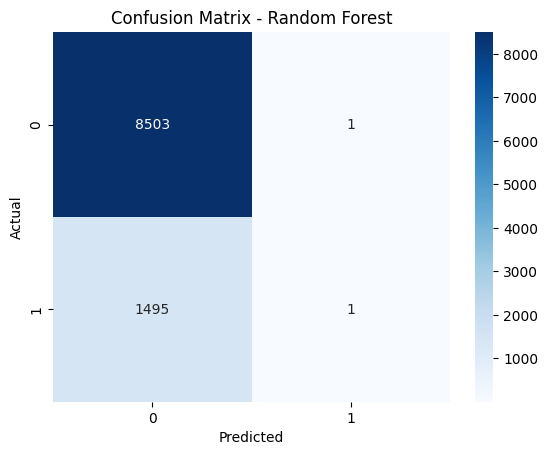

In [11]:
# 9. Hold‑out evaluation

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC‑AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [12]:
# 10. Cross‑validation for more robust performance estimate

cv_scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc", n_jobs=-1)
print("CV ROC‑AUC scores:", cv_scores)
print("CV ROC‑AUC mean:", cv_scores.mean())
print("CV ROC‑AUC std:", cv_scores.std())

CV ROC‑AUC scores: [0.69440553 0.49180262 0.34706678 0.41823583 0.74246737]
CV ROC‑AUC mean: 0.5387956254769501
CV ROC‑AUC std: 0.15440180149746544


C:\Users\Utham\AppData\Local\Temp\ipykernel_36640\1505965219.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


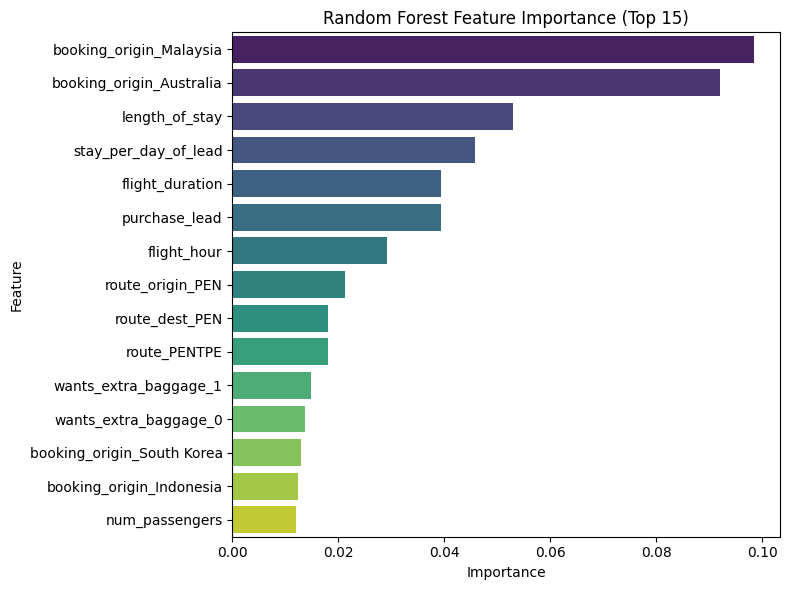

In [13]:
# 11. Feature importance extraction
# Need to rebuild preprocessing separately so we can see feature names

# Fit preprocessor alone on full data
preprocessor.fit(X)

# Get transformed feature names
cat_ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = list(cat_ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

# Fit RF on fully transformed data
X_transformed = preprocessor.transform(X)
rf_clf.fit(X_transformed, y)

importances = rf_clf.feature_importances_

feat_imp = pd.DataFrame(
    {"feature": all_feature_names, "importance": importances}
).sort_values("importance", ascending=False)

# Take top 15 for plotting
top_k = 15
top_feat = feat_imp.head(top_k)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_feat,
    y="feature",
    x="importance",
    orient="h",
    palette="viridis",
)
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Save feature importance table for use in your slide
feat_imp.to_csv("feature_importance_random_forest.csv", index=False)